# Detekcija lažnih oglasa za posao

Predmet analize je binarna klasifikacija oglasa za posao na klase `real` i `fake`. Ispituje se kako kvalitet teksta, različiti postupci predobrade i izbor tekstualne reprezentacije utiču na performanse klasifikacionih modela.

## 1. Tok analize

Analiza je organizovana u nekoliko povezanih celina:

1. učitavanje i početni pregled skupa podataka
2. merenje kvaliteta teksta i prisustva šuma
3. word, sentence i subword tokenizacija
4. formiranje različitih verzija predobrađenog teksta
5. proširivanje trening podataka i kontrolisano dodavanje šuma
6. poređenje Bag of Words, TF-IDF i gustih reprezentacija
7. treniranje Word2Vec, FastText-style i BERT-like modela
8. evaluacija, analiza robusnosti i pregled pogrešnih predikcija

Word2Vec, FastText-style i BERT-like modeli treniraju se lokalno na posmatranom skupu. Njihovi rezultati zato odražavaju količinu i raznovrsnost dostupnih trening podataka, bez korišćenja spoljnih pretrained težina.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import random
import re
import string
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from scipy.sparse import hstack

from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Učitavanje skupa podataka

Skup sadrži tekstualne i strukturirane podatke o oglasima za posao, kao i binarnu ciljnu promenljivu `is_fake`. Tekstualne kolone `job_title`, `job_description`, `requirements`, `benefits` i `company_profile` spajaju se u jedinstveno polje `full_text`.

Početni pregled obuhvata dimenzije skupa, tipove podataka, nedostajuće vrednosti, raspodelu ciljnih klasa i prisustvo duplikata.

In [2]:
DATASET_PATH = "fake_real_job_postings.csv"

df = pd.read_csv(DATASET_PATH)

TEXT_COLUMNS = ["job_title", "job_description", "requirements", "benefits", "company_profile"]
TARGET = "is_fake"

df["full_text"] = df[TEXT_COLUMNS].fillna("").agg(" ".join, axis=1)
df["label"] = df[TARGET].map({0: "real", 1: "fake"})

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (3000, 27)


,job_id,job_title,job_description,requirements,benefits,company_name,company_profile,industry,employment_type,location,...,company_website,has_logo,num_open_positions,job_function,telecommuting,fraud_reason,text_length,is_fake,full_text,label
0,1,Data Analyst,Successful candidates communicate clearly with...,"THE WORK REQUIRES ATTENTION TO DETAIL, CLEAR H...","Bonus eligibility depends on team results, del...",BrightPath Solutions,Teams are small enough for direct collaboratio...,Software,Part-time,"Budapest, Hungary",...,https://www.brightpathsolutions.eu,1,3,Analysis,0,NaN,1634,0,Data Analyst Successful candidates communicate...,real
1,2,Content Strategist,"The work requires attention to detail, clear h...",Candidates should be comfortable learning inte...,Flexible working hours with agreed core collab...,OakLine Holdings,Our recruiters may represent more than one con...,Logistics,Internship,Remote,...,https://www.oaklineholdings.co,1,1,Design,1,NaN,1558,0,Content Strategist The work requires attention...,real
2,3,Data Analyst,Successful candidates communicate clearly with...,Candidates should be comfortable learning inte...,MANAGER SUPPORT DURING ONBOARDING AND ACCESS T...,SilverFern Holdings,The company builds long-term client relationsh...,Human Resources,Part-time,"Novi Sad, Serbia",...,https://www.silverfernholdings.eu,1,2,Analysis,0,NaN,1679,0,Data Analyst Successful candidates communicate...,real
3,4,Software Engineer,We are looking for someone who can balance day...,Our team works in short planning cycles and us...,"Bonus eligibility depends on team results, del...",OakLine Collective,Current growth has outpaced some internal syst...,Education,Full-time,"Berlin, Germany",...,https://www.oaklinecollective.eu,1,3,Development,0,NaN,1529,0,Software Engineer We are looking for someone w...,real
4,5,Data Analyst,Candidates should be comfortable learning inte...,You will partner with cross-functional te@mmat...,A mix of independent work and regular team che...,BlueCedar Solutions,Our Recruiters May Represent More Than One Con...,Education,Full-time,"Budapest, Hungary",...,https://www.bluecedarsolutions.rs,1,1,Analysis,0,NaN,1904,1,Data Analyst Candidates should be comfortable ...,fake


In [3]:
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(),
    }
).sort_values(["missing_percent", "unique_values"], ascending=[False, False])

display(summary)
display(df[TARGET].value_counts().rename(index={0: "real", 1: "fake"}).to_frame("count"))


,dtype,missing,missing_percent,unique_values
fraud_reason,object,2804,93.47,5
company_website,object,380,12.67,480
job_id,int64,0,0.00,3000
full_text,object,0,0.00,3000
job_description,object,0,0.00,2996
benefits,object,0,0.00,2862
requirements,object,0,0.00,2838
company_profile,object,0,0.00,2086
contact_email,object,0,0.00,1724
text_length,int64,0,0.00,1011


,count
is_fake,
real,1500
fake,1500


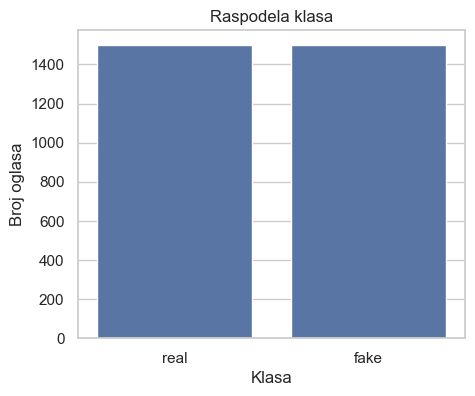

Duplicirani redovi: 0
Duplicirani full_text tekstovi: 0


In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="label", order=["real", "fake"])
plt.title("Raspodela klasa")
plt.xlabel("Klasa")
plt.ylabel("Broj oglasa")
plt.show()

print("Duplicirani redovi:", df.duplicated().sum())
print("Duplicirani full_text tekstovi:", df["full_text"].duplicated().sum())


## 3. Kvalitet tekstualnih podataka

Kvalitet teksta posmatra se kroz dužinu dokumenata, veličinu rečnika, leksičku raznovrsnost i prisustvo šuma. Metrike se računaju po dokumentu, a zatim porede između stvarnih i lažnih oglasa.

Analiziraju se tri grupe pokazatelja:

- **strukturne osobine**: broj karaktera, reči i rečenica, prosečna dužina reči i lexical diversity
- **direktno uočljiv šum**: HTML, emoji, URL, email adrese, brojevi, interpunkcija i velika slova
- **indikatori nepravilnog teksta**: tipografske i OCR-like zamene, spam fraze i ponovljena interpunkcija

Ove osobine opisuju razlike u načinu pisanja oglasa i kasnije se koriste za proveru njihove vrednosti kao dodatnih ulaznih atributa.

In [5]:
WORD_RE = re.compile(r"\b[^\W\d_][\w@\-']*\b", re.UNICODE)
SENTENCE_RE = re.compile(r"(?<=[.!?])\s+")
HTML_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
EMOJI_RE = re.compile(
    "[" "\U0001F300-\U0001FAFF" "\U00002700-\U000027BF" "\U00002600-\U000026FF" "]",
    flags=re.UNICODE,
)
TYPO_RE = re.compile(r"\b\w*(?:[a-z][0@1][a-z]|[a-z]+[-@][a-z]+)\w*\b", re.I)
OCR_RE = re.compile(r"\b\w*(?:[a-z][01][a-z]|rn|cl)\w*\b", re.I)
SPAM_RE = re.compile(
    r"\b(?:urgent|immediate start|easy money|earn \$?|limited time|act now|no experience|"
    r"guaranteed income|wire transfer|crypto|whatsapp|telegram)\b", re.I
)


def word_tokens(text: str) -> list[str]:
    return WORD_RE.findall(str(text).lower())


def sentence_tokens(text: str) -> list[str]:
    return [s.strip() for s in SENTENCE_RE.split(str(text)) if s.strip()]


def lexical_diversity(tokens: list[str]) -> float:
    return len(set(tokens)) / len(tokens) if tokens else 0.0


def uppercase_ratio(text: str) -> float:
    chars = [ch for ch in str(text) if ch.isalpha()]
    return sum(ch.isupper() for ch in chars) / len(chars) if chars else 0.0


def punctuation_ratio(text: str) -> float:
    text = str(text)
    return sum(ch in string.punctuation for ch in text) / len(text) if text else 0.0


def non_ascii_ratio(text: str) -> float:
    text = str(text)
    return sum(ord(ch) > 127 for ch in text) / len(text) if text else 0.0


df["word_tokens"] = df["full_text"].apply(word_tokens)
df["char_length"] = df["full_text"].str.len()
df["word_count"] = df["word_tokens"].apply(len)
df["sentence_count"] = df["full_text"].apply(lambda x: len(sentence_tokens(x)))
df["avg_word_length"] = df["word_tokens"].apply(lambda x: np.mean([len(t) for t in x]) if x else 0)
df["lexical_diversity"] = df["word_tokens"].apply(lexical_diversity)
df["html_tag_count"] = df["full_text"].apply(lambda x: len(HTML_RE.findall(str(x))))
df["url_count"] = df["full_text"].apply(lambda x: len(URL_RE.findall(str(x))))
df["email_count"] = df["full_text"].apply(lambda x: len(EMAIL_RE.findall(str(x))))
df["emoji_count"] = df["full_text"].apply(lambda x: len(EMOJI_RE.findall(str(x))))
df["spam_phrase_count"] = df["full_text"].apply(lambda x: len(SPAM_RE.findall(str(x))))
df["repeated_punctuation_count"] = df["full_text"].str.count(r"[!?]{2,}")
df["digit_count"] = df["full_text"].apply(lambda x: sum(ch.isdigit() for ch in str(x)))
df["punctuation_ratio"] = df["full_text"].apply(punctuation_ratio)
df["uppercase_ratio"] = df["full_text"].apply(uppercase_ratio)
df["non_ascii_ratio"] = df["full_text"].apply(non_ascii_ratio)
df["typo_proxy_count"] = df["full_text"].apply(lambda x: len(TYPO_RE.findall(str(x))))
df["ocr_proxy_count"] = df["full_text"].apply(lambda x: len(OCR_RE.findall(str(x))))

QUALITY_COLUMNS = [
    "char_length", "word_count", "sentence_count", "avg_word_length",
    "lexical_diversity", "html_tag_count", "url_count", "email_count",
    "emoji_count", "spam_phrase_count", "repeated_punctuation_count",
    "digit_count", "punctuation_ratio", "uppercase_ratio", "non_ascii_ratio",
    "typo_proxy_count", "ocr_proxy_count",
]

display(df.groupby("label")[QUALITY_COLUMNS].mean().round(3).T)

noise_presence = pd.DataFrame({
    "noise_type": ["HTML", "emoji", "spam phrase", "repeated punctuation", "typo proxy", "OCR proxy"],
    "documents_with_noise": [
        (df["html_tag_count"] > 0).sum(), (df["emoji_count"] > 0).sum(),
        (df["spam_phrase_count"] > 0).sum(), (df["repeated_punctuation_count"] > 0).sum(),
        (df["typo_proxy_count"] > 0).sum(), (df["ocr_proxy_count"] > 0).sum(),
    ],
})
display(noise_presence)

label,fake,real
char_length,1959.599,1577.150
word_count,270.377,216.057
sentence_count,17.619,14.501
avg_word_length,6.088,6.126
lexical_diversity,0.636,0.662
html_tag_count,0.245,0.172
url_count,0.000,0.000
email_count,0.000,0.000
emoji_count,0.000,0.000
spam_phrase_count,0.329,0.034


,noise_type,documents_with_noise
0,HTML,306
1,emoji,0
2,spam phrase,489
3,repeated punctuation,0
4,typo proxy,2998
5,OCR proxy,3000


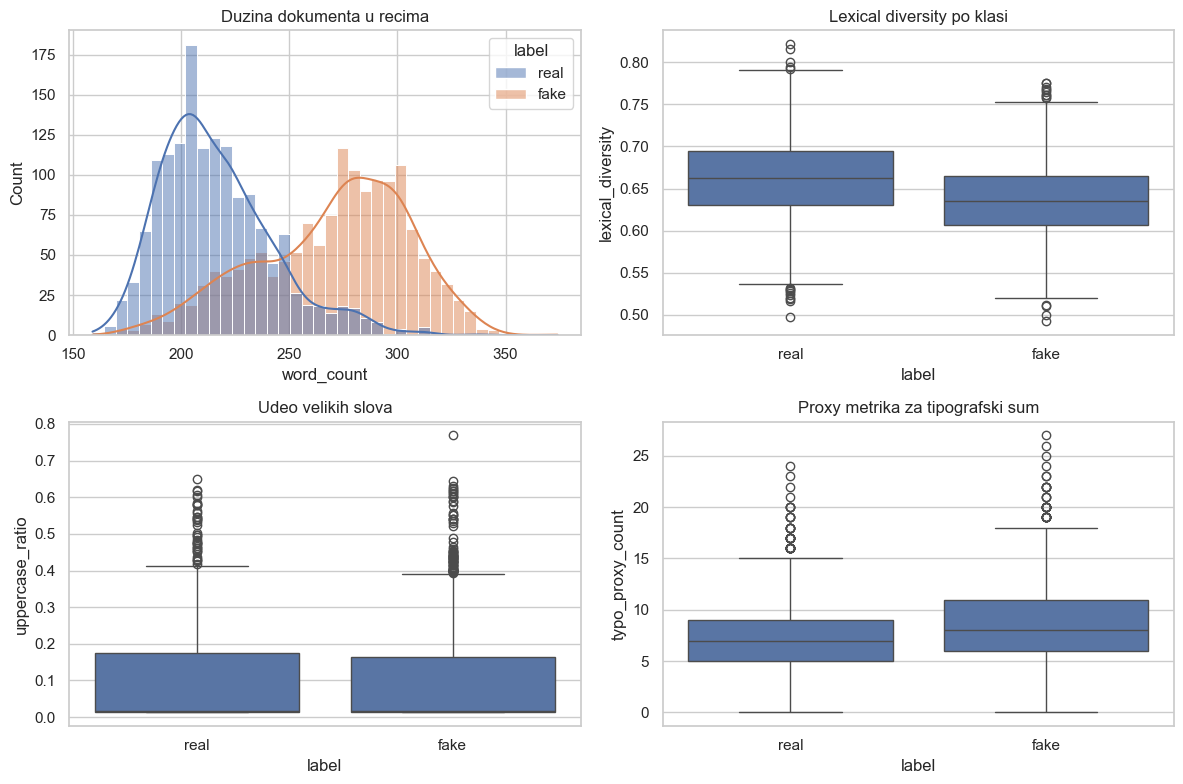

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(data=df, x="word_count", hue="label", bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Duzina dokumenta u recima")
sns.boxplot(data=df, x="label", y="lexical_diversity", order=["real", "fake"], ax=axes[0, 1])
axes[0, 1].set_title("Lexical diversity po klasi")
sns.boxplot(data=df, x="label", y="uppercase_ratio", order=["real", "fake"], ax=axes[1, 0])
axes[1, 0].set_title("Udeo velikih slova")
sns.boxplot(data=df, x="label", y="typo_proxy_count", order=["real", "fake"], ax=axes[1, 1])
axes[1, 1].set_title("Proxy metrika za tipografski sum")
plt.tight_layout()
plt.show()


In [7]:
def vocabulary_stats(frame: pd.DataFrame, text_col: str) -> pd.DataFrame:
    rows = []
    for label, part in frame.groupby("label"):
        tokens = [token for tokens in part[text_col].apply(word_tokens) for token in tokens]
        counter = Counter(tokens)
        rows.append(
            {
                "class": label,
                "total_tokens": len(tokens),
                "vocabulary_size": len(counter),
                "hapax_tokens": sum(1 for value in counter.values() if value == 1),
                "top_10_tokens": ", ".join(token for token, _ in counter.most_common(10)),
            }
        )
    return pd.DataFrame(rows)


display(vocabulary_stats(df, "full_text"))


,class,total_tokens,vocabulary_size,hapax_tokens,top_10_tokens
0,fake,405566,1174,307,"and, the, to, with, a, are, in, may, internal,..."
1,real,324086,1155,292,"and, with, to, the, a, in, are, role, internal..."


## 4. Tokenizacija: word, sentence i subword pristup

Tekst se razlaže na tri nivoa:

- **word tokeni** čine osnovu klasičnih vektorskih reprezentacija i Word2Vec modela
- **sentence tokeni** opisuju strukturu i dužinu dokumenta
- **subword tokeni** obuhvataju karakterske n-grame i BPE jedinice, korisne za retke, nepoznate i pogrešno napisane reči

BPE iterativno spaja najčešće susedne simbole i gradi rečnik podreči. Na taj način reči koje nisu prisutne u rečniku mogu da se predstave kombinacijom poznatih delova.

In [8]:
example_idx = 0
example_text = df.loc[example_idx, "full_text"]

def character_ngrams(text: str, n: int = 4, limit: int = 25) -> list[str]:
    compact = re.sub(r"\s+", " ", str(text).lower()).strip()
    grams = [compact[i : i + n] for i in range(max(0, len(compact) - n + 1))]
    return grams[:limit]


tokenization_preview = pd.DataFrame(
    {
        "word_tokens_first_25": [word_tokens(example_text)[:25]],
        "sentence_tokens_first_5": [sentence_tokens(example_text)[:5]],
        "char_4grams_first_25": [character_ngrams(example_text, n=4, limit=25)],
    }
).T

display(tokenization_preview)


,0
word_tokens_first_25,"[data, analyst, successful, candidates, commun..."
sentence_tokens_first_5,[Data Analyst Successful candidates communicat...
char_4grams_first_25,"[data, ata , ta a, a an, ana, anal, naly, aly..."


### 4.1 BPE subword tokenizacija

BPE pravila spajanja uče se isključivo na trening delu skupa. Primeri prikazuju razlaganje pravilno napisane reči, njene tipografske varijante i reči koja nije viđena tokom učenja tokenizatora.

In [9]:
def learn_bpe(texts, num_merges=80, max_words=12000):
    counts = Counter(token for text in texts for token in word_tokens(text))
    vocab = {tuple(list(word) + ["</w>"]): count for word, count in counts.most_common(max_words)}
    merges = []
    for _ in range(num_merges):
        pairs = Counter()
        for symbols, count in vocab.items():
            pairs.update({pair: count for pair in zip(symbols, symbols[1:])})
        if not pairs:
            break
        best = pairs.most_common(1)[0][0]
        merges.append(best)
        new_vocab = {}
        for symbols, count in vocab.items():
            out, i = [], 0
            while i < len(symbols):
                if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == best:
                    out.append(symbols[i] + symbols[i + 1])
                    i += 2
                else:
                    out.append(symbols[i])
                    i += 1
            new_vocab[tuple(out)] = new_vocab.get(tuple(out), 0) + count
        vocab = new_vocab
    return merges


def bpe_word(word, merges):
    symbols = list(word.lower()) + ["</w>"]
    for pair in merges:
        out, i = [], 0
        while i < len(symbols):
            if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
                out.append(symbols[i] + symbols[i + 1])
                i += 2
            else:
                out.append(symbols[i])
                i += 1
        symbols = out
    return [s.replace("</w>", "") for s in symbols if s != "</w>"]


bpe_train_idx, _ = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=df[TARGET]
)
bpe_merges = learn_bpe(df.loc[bpe_train_idx, "full_text"], num_merges=80)
examples = ["communication", "communicat1on", "applicants", "unseenword"]
display(pd.DataFrame({
    "word": examples,
    "BPE_subwords": [bpe_word(word, bpe_merges) for word in examples],
}))


,word,BPE_subwords
0,communication,"[com, m, un, i, c, ation]"
1,communicat1on,"[com, m, un, i, c, a, t, 1, on]"
2,applicants,"[a, pp, li, can, ts]"
3,unseenword,"[un, s, e, en, wor, d]"


## 5. Predobrada teksta

Od početnog teksta formira se pet varijanti:

- `raw_text`: originalni spojeni tekst oglasa
- `normalized_text`: tekst nakon uklanjanja HTML-a, URL-ova, email adresa, brojeva, interpunkcije i emoji simbola, uz NFKC Unicode normalizaciju i case folding
- `no_stopwords_text`: normalizovan tekst bez engleskih stop-reči
- `stemmed_text`: tekst obrađen Porter stemmerom
- `lemmatized_text`: tekst obrađen WordNet lematizatorom

Stemming agresivno svodi reči na zajedničku osnovu, dok lematizacija pokušava da sačuva validniji oblik reči. Promene broja tokena i veličine rečnika pokazuju koliko svaki postupak sažima tekstualni prostor.

In [10]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def strip_html(text: str) -> str:
    return BeautifulSoup(str(text), "html.parser").get_text(" ")


def normalize_text(text: str) -> str:
    text = strip_html(text)
    text = unicodedata.normalize("NFKC", str(text)).casefold()
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = EMOJI_RE.sub(" ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    return re.sub(r"\s+", " ", text).strip()


def remove_stopwords(text: str) -> str:
    return " ".join(t for t in str(text).split() if t not in ENGLISH_STOP_WORDS)


def stem_text(text: str) -> str:
    return " ".join(stemmer.stem(t) for t in str(text).split())


def lemmatize_text(text: str) -> str:
    return " ".join(lemmatizer.lemmatize(t) for t in str(text).split())


df["raw_text"] = df["full_text"]
df["normalized_text"] = df["raw_text"].apply(normalize_text)
df["no_stopwords_text"] = df["normalized_text"].apply(remove_stopwords)
df["stemmed_text"] = df["no_stopwords_text"].apply(stem_text)
df["lemmatized_text"] = df["no_stopwords_text"].apply(lemmatize_text)

display(pd.DataFrame({
    c: [df.loc[0, c][:260]]
    for c in ["raw_text", "normalized_text", "no_stopwords_text", "stemmed_text", "lemmatized_text"]
}).T)

,0
raw_text,Data Analyst Successful candidates communicate...
normalized_text,data analyst successful candidates communicate...
no_stopwords_text,data analyst successful candidates communicate...
stemmed_text,data analyst success candid commun clearli sta...
lemmatized_text,data analyst successful candidate communicate ...


In [11]:
preprocessing_stats = []
for column in ["raw_text", "normalized_text", "no_stopwords_text", "stemmed_text", "lemmatized_text"]:
    tokens = [token for text in df[column] for token in str(text).split()]
    preprocessing_stats.append(
        {
            "text_variant": column,
            "total_tokens": len(tokens),
            "vocabulary_size": len(set(tokens)),
            "avg_tokens_per_doc": round(np.mean([len(str(text).split()) for text in df[column]]), 2),
        }
    )

display(pd.DataFrame(preprocessing_stats))


,text_variant,total_tokens,vocabulary_size,avg_tokens_per_doc
0,raw_text,747050,2659,249.02
1,normalized_text,733301,483,244.43
2,no_stopwords_text,487747,412,162.58
3,stemmed_text,487747,347,162.58
4,lemmatized_text,487747,394,162.58


## 6. Proširivanje podataka

Trening skup se proširuje kontrolisanim transformacijama teksta: pojedine domenske reči zamenjuju se sinonimima, a mali procenat tokena se nasumično uklanja. Transformacije se primenjuju samo na trening podatke kako izmenjene verzije test dokumenata ne bi uticale na procenu modela.

Originalni i izmenjeni dokumenti zadržavaju istu ciljnu klasu. Njihovo zajedničko korišćenje povećava jezičku varijabilnost podataka dostupnih modelu.

In [12]:
SYNONYMS = {
    "job": ["position", "role"],
    "role": ["position", "job"],
    "team": ["group", "staff"],
    "candidate": ["applicant"],
    "candidates": ["applicants"],
    "company": ["organization"],
    "work": ["tasks"],
    "remote": ["online"],
    "support": ["assist"],
    "communication": ["collaboration"],
    "skills": ["abilities"],
    "experience": ["background"],
}


def augment_text(text: str, rng: random.Random, replacement_prob: float = 0.12, deletion_prob: float = 0.03) -> str:
    augmented = []
    for token in str(text).split():
        if rng.random() < deletion_prob and len(token) > 3:
            continue
        if token in SYNONYMS and rng.random() < replacement_prob:
            augmented.append(rng.choice(SYNONYMS[token]))
        else:
            augmented.append(token)
    return " ".join(augmented)


example_augmented = augment_text(df.loc[0, "normalized_text"], random.Random(RANDOM_STATE))
display(pd.DataFrame({"original": [df.loc[0, "normalized_text"][:260]], "augmented": [example_augmented[:260]]}).T)


,0
original,data analyst successful candidates communicate...
augmented,data successful candidates communicate clearly...


### 6.1 Kontrolisano dodavanje šuma

Za analizu robusnosti formira se izmenjena verzija test teksta sa HTML oznakama, emoji simbolom, spam frazom i manjim brojem OCR/typo zamena. Ovaj skup predstavlja kontrolisani scenario degradacije kvaliteta teksta.

Modeli se i dalje treniraju na čistim dokumentima, dok se njihove predikcije porede na čistoj i izmenjenoj verziji test skupa.

In [13]:
def inject_noise(text, rng):
    tokens = str(text).split()
    noisy = []
    for token in tokens:
        if len(token) > 5 and rng.random() < 0.035:
            pos = rng.randrange(1, len(token) - 1)
            token = token[:pos] + rng.choice(["0", "1", "@"]) + token[pos + 1:]
        noisy.append(token)
    return "<div>" + " ".join(noisy) + "</div> 🚀 ACT NOW!!!"


noise_rng = random.Random(RANDOM_STATE)
noise_preview = inject_noise(df.loc[0, "full_text"][:300], noise_rng)
display(pd.DataFrame({"clean": [df.loc[0, "full_text"][:300]], "noisy": [noise_preview]}).T)


,0
clean,Data Analyst Successful candidates communicate...
noisy,<div>Data Analyst Succe0sful candidates commun...


## 7. Klasični modeli, reprezentacije i evaluacija

Bag of Words i TF-IDF reprezentacije primenjuju se na različite varijante predobrade. Time se odvojeno posmatraju efekti normalizacije, uklanjanja stop-reči, stemminga i lematizacije.

Pored word reprezentacija koriste se:

- character n-gram TF-IDF kao subword reprezentacija otporna na manje izmene reči
- TF-IDF sa metrikama kvaliteta teksta
- TF-IDF praćen LSA redukcijom dimenzionalnosti kao gusta reprezentacija

Logistička regresija i Multinomial Naive Bayes evaluiraju se pomoću accuracy, precision, recall i F1 mera.

In [14]:
print("TensorFlow/Keras dostupan:", tf.__version__)
print("Napomena: neuronski modeli ispod treniraju se lokalno; ne koriste pretrained težine.")

TensorFlow/Keras dostupan: 2.20.0
Napomena: neuronski modeli ispod treniraju se lokalno; ne koriste pretrained težine.


In [15]:
y = df[TARGET].astype(int)
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Test class distribution:")
display(y.loc[test_idx].value_counts().sort_index().rename(index={0: "real", 1: "fake"}).to_frame("count"))


Train size: 2400
Test size: 600
Test class distribution:


,count
is_fake,
real,300
fake,300


In [16]:
def build_vectorizer(kind: str):
    if kind == "bow":
        return CountVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2)
    if kind == "tfidf_word":
        return TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2, sublinear_tf=True, strip_accents="unicode")
    if kind == "tfidf_char":
        return TfidfVectorizer(max_features=12000, analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)
    raise ValueError(f"Nepoznata reprezentacija: {kind}")


def build_estimator(model_name: str):
    if model_name == "LogisticRegression":
        return LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
    if model_name == "MultinomialNB":
        return MultinomialNB()
    raise ValueError(f"Nepoznat model: {model_name}")


def augment_training_set(texts: pd.Series, labels: pd.Series) -> tuple[pd.Series, pd.Series]:
    rng = random.Random(RANDOM_STATE)
    augmented_texts = texts.apply(lambda text: augment_text(text, rng))
    return pd.concat([texts, augmented_texts], ignore_index=True), pd.concat([labels, labels], ignore_index=True)


def evaluate_config(config: dict) -> dict:
    text_col = config["text_col"]
    X_train = df.loc[train_idx, text_col].astype(str)
    X_test = df.loc[test_idx, text_col].astype(str)
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    if config.get("augment", False):
        X_train, y_train = augment_training_set(X_train.reset_index(drop=True), y_train.reset_index(drop=True))

    if config.get("dense_lsa", False):
        estimator = Pipeline(
            [
                ("tfidf", build_vectorizer("tfidf_word")),
                ("svd", TruncatedSVD(n_components=120, random_state=RANDOM_STATE)),
                ("clf", build_estimator(config["model"])),
            ]
        )
        estimator.fit(X_train, y_train)
        y_pred = estimator.predict(X_test)
        fitted = estimator
    else:
        vectorizer = build_vectorizer(config["vectorizer"])
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)

        scaler = None
        if config.get("quality_features", False):
            scaler = StandardScaler()
            train_quality = scaler.fit_transform(df.loc[train_idx, QUALITY_COLUMNS])
            test_quality = scaler.transform(df.loc[test_idx, QUALITY_COLUMNS])
            if config.get("augment", False):
                train_quality = np.vstack([train_quality, train_quality])
            X_train_vec = hstack([X_train_vec, train_quality])
            X_test_vec = hstack([X_test_vec, test_quality])

        estimator = build_estimator(config["model"])
        estimator.fit(X_train_vec, y_train)
        y_pred = estimator.predict(X_test_vec)
        fitted = {"vectorizer": vectorizer, "model": estimator, "scaler": scaler}

    return {
        "experiment": config["name"],
        "text_variant": text_col,
        "representation": config.get("representation", config.get("vectorizer", "dense_lsa")),
        "model": config["model"],
        "augmented_train": config.get("augment", False),
        "quality_features": config.get("quality_features", False),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, target_names=["real", "fake"]),
        "y_pred": y_pred,
        "fitted": fitted,
    }


In [17]:
EXPERIMENTS = [
    {"name": "BoW raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "bow", "representation": "Bag of Words", "model": "LogisticRegression"},
    {"name": "BoW normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "bow", "representation": "Bag of Words", "model": "LogisticRegression"},
    {"name": "BoW no stopwords + LogisticRegression", "text_col": "no_stopwords_text", "vectorizer": "bow", "representation": "Bag of Words", "model": "LogisticRegression"},
    {"name": "BoW stemmed + LogisticRegression", "text_col": "stemmed_text", "vectorizer": "bow", "representation": "Bag of Words", "model": "LogisticRegression"},
    {"name": "BoW lemmatized + LogisticRegression", "text_col": "lemmatized_text", "vectorizer": "bow", "representation": "Bag of Words", "model": "LogisticRegression"},
    {"name": "BoW raw + MultinomialNB", "text_col": "raw_text", "vectorizer": "bow", "representation": "Bag of Words", "model": "MultinomialNB"},
    {"name": "TF-IDF raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF no stopwords + LogisticRegression", "text_col": "no_stopwords_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + LogisticRegression", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF lemmatized + LogisticRegression", "text_col": "lemmatized_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + MultinomialNB", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "MultinomialNB"},
    {"name": "Subword char ngrams + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_char", "representation": "Character n-gram TF-IDF", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + quality features", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "representation": "TF-IDF + quality metrics", "model": "LogisticRegression", "quality_features": True},
    {"name": "Dense LSA baseline + LogisticRegression", "text_col": "normalized_text", "representation": "Dense LSA baseline", "model": "LogisticRegression", "dense_lsa": True},
    {"name": "Augmented TF-IDF normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_word", "representation": "TF-IDF with train augmentation", "model": "LogisticRegression", "augment": True},
]

results = [evaluate_config(config) for config in EXPERIMENTS]
results_df = pd.DataFrame(
    [{key: value for key, value in row.items() if key not in {"confusion_matrix", "classification_report", "y_pred", "fitted"}} for row in results]
).sort_values("f1", ascending=False)

display(results_df.reset_index(drop=True))


,experiment,text_variant,representation,model,augmented_train,quality_features,accuracy,precision,recall,f1
0,Subword char ngrams + LogisticRegression,normalized_text,Character n-gram TF-IDF,LogisticRegression,False,False,0.823333,0.854015,0.780000,0.815331
1,TF-IDF raw + LogisticRegression,raw_text,TF-IDF word ngrams,LogisticRegression,False,False,0.820000,0.842857,0.786667,0.813793
2,TF-IDF stemmed + LogisticRegression,stemmed_text,TF-IDF word ngrams,LogisticRegression,False,False,0.820000,0.842857,0.786667,0.813793
3,Dense LSA baseline + LogisticRegression,normalized_text,Dense LSA baseline,LogisticRegression,False,False,0.820000,0.842857,0.786667,0.813793
4,BoW raw + MultinomialNB,raw_text,Bag of Words,MultinomialNB,False,False,0.823333,0.864662,0.766667,0.812721
5,TF-IDF stemmed + MultinomialNB,stemmed_text,TF-IDF word ngrams,MultinomialNB,False,False,0.823333,0.864662,0.766667,0.812721
6,Augmented TF-IDF normalized + LogisticRegression,normalized_text,TF-IDF with train augmentation,LogisticRegression,True,False,0.813333,0.819728,0.803333,0.811448
7,TF-IDF normalized + LogisticRegression,normalized_text,TF-IDF word ngrams,LogisticRegression,False,False,0.816667,0.836879,0.786667,0.810997
8,TF-IDF no stopwords + LogisticRegression,no_stopwords_text,TF-IDF word ngrams,LogisticRegression,False,False,0.816667,0.836879,0.786667,0.810997
9,TF-IDF lemmatized + LogisticRegression,lemmatized_text,TF-IDF word ngrams,LogisticRegression,False,False,0.816667,0.836879,0.786667,0.810997


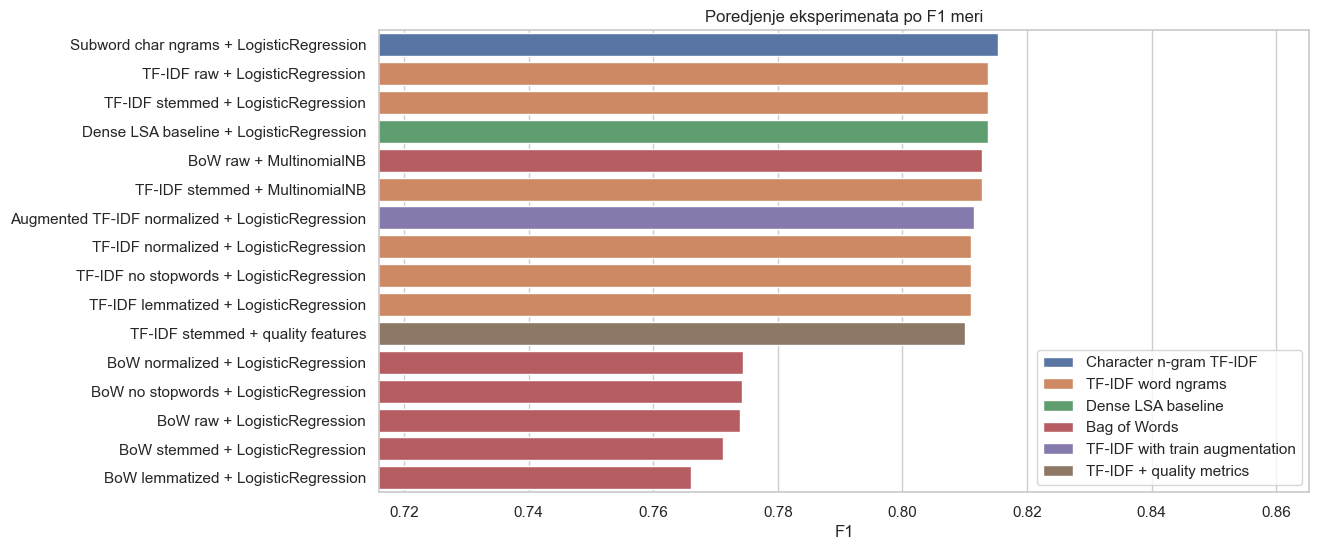

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="f1", y="experiment", hue="representation", dodge=False)
plt.title("Poredjenje eksperimenata po F1 meri")
plt.xlabel("F1")
plt.ylabel("")
plt.xlim(max(0, results_df["f1"].min() - 0.05), min(1, results_df["f1"].max() + 0.05))
plt.legend(loc="lower right")
plt.show()


## 8. Unakrsna validacija

Rezultat jednog train/test deljenja može zavisiti od konkretnih dokumenata koji su završili u test skupu. Za stabilniju procenu glavne konfiguracije se dodatno evaluiraju stratifikovanom petostrukom unakrsnom validacijom.

Srednje vrednosti i standardne devijacije pokazuju prosečne performanse i osetljivost modela na promenu trening i validacionih podskupova.

In [19]:
CV_EXPERIMENTS = [
    {"name": "BoW raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "bow", "model": "LogisticRegression"},
    {"name": "BoW normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "bow", "model": "LogisticRegression"},
    {"name": "BoW stemmed + LogisticRegression", "text_col": "stemmed_text", "vectorizer": "bow", "model": "LogisticRegression"},
    {"name": "TF-IDF raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF no stopwords + LogisticRegression", "text_col": "no_stopwords_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + LogisticRegression", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF lemmatized + LogisticRegression", "text_col": "lemmatized_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "Subword char ngrams + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_char", "model": "LogisticRegression"},
    {"name": "Dense LSA baseline + LogisticRegression", "text_col": "normalized_text", "model": "LogisticRegression", "dense_lsa": True},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1"}

cv_rows = []
for config in CV_EXPERIMENTS:
    if config.get("dense_lsa", False):
        estimator = Pipeline(
            [
                ("tfidf", build_vectorizer("tfidf_word")),
                ("svd", TruncatedSVD(n_components=120, random_state=RANDOM_STATE)),
                ("clf", build_estimator(config["model"])),
            ]
        )
    else:
        estimator = Pipeline(
            [
                ("vectorizer", build_vectorizer(config["vectorizer"])),
                ("clf", build_estimator(config["model"])),
            ]
        )

    scores = cross_validate(estimator, df[config["text_col"]], y, cv=cv, scoring=scoring)
    cv_rows.append(
        {
            "experiment": config["name"],
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std": scores["test_accuracy"].std(),
            "precision_mean": scores["test_precision"].mean(),
            "recall_mean": scores["test_recall"].mean(),
            "f1_mean": scores["test_f1"].mean(),
            "f1_std": scores["test_f1"].std(),
        }
    )

cv_results_df = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False)
display(cv_results_df.round(4).reset_index(drop=True))


,experiment,accuracy_mean,accuracy_std,precision_mean,recall_mean,f1_mean,f1_std
0,TF-IDF normalized + LogisticRegression,0.8343,0.0128,0.8979,0.7547,0.8198,0.0162
1,TF-IDF lemmatized + LogisticRegression,0.8340,0.0126,0.8998,0.7520,0.8190,0.0158
2,TF-IDF stemmed + LogisticRegression,0.8337,0.0127,0.8990,0.7520,0.8187,0.0157
3,TF-IDF raw + LogisticRegression,0.8333,0.0128,0.8971,0.7533,0.8186,0.0162
4,TF-IDF no stopwords + LogisticRegression,0.8333,0.0130,0.8990,0.7513,0.8182,0.0163
5,Dense LSA baseline + LogisticRegression,0.8327,0.0116,0.9001,0.7487,0.8172,0.0144
6,Subword char ngrams + LogisticRegression,0.8317,0.0110,0.9005,0.7460,0.8157,0.0140
7,BoW stemmed + LogisticRegression,0.7850,0.0133,0.7880,0.7800,0.7836,0.0169
8,BoW raw + LogisticRegression,0.7853,0.0173,0.7916,0.7747,0.7829,0.0190
9,BoW normalized + LogisticRegression,0.7843,0.0183,0.7931,0.7693,0.7807,0.0217


## 9. Word embeddings i BERT-like Transformer

Guste reprezentacije teksta formiraju se pomoću tri lokalno trenirana modela:

1. **Word2Vec (CBOW)** uči embedding reči predviđanjem centralne reči na osnovu njenog konteksta. Dokument se predstavlja prosekom embeddinga njegovih reči.
2. **FastText-style model** kombinuje word embeddinge sa embeddingom hashiranih karakterskih 3–5-grama. Subword informacije omogućavaju predstavljanje tipografskih varijanti i reči van poznatog rečnika.
3. **BERT-like model** koristi BPE subword tokene, pozicione embeddinge, multi-head self-attention, feed-forward blok i klasifikacioni izlaz.

Ovi modeli uče reprezentacije od nule na trening delu skupa. Njihove performanse zato se posmatraju kao rezultat lokalnog učenja, a ne prenosa znanja iz velikog jezičkog korpusa.

In [20]:
MAX_VOCAB = 2500
EMBED_DIM = 48
MAX_LEN = 140

train_texts = df.loc[train_idx, "normalized_text"].astype(str)
test_texts = df.loc[test_idx, "normalized_text"].astype(str)
y_train_nn = y.loc[train_idx].to_numpy()
y_test_nn = y.loc[test_idx].to_numpy()

vectorize = layers.TextVectorization(
    max_tokens=MAX_VOCAB, output_mode="int", output_sequence_length=MAX_LEN,
    standardize=None, split="whitespace",
)
vectorize.adapt(train_texts.to_numpy())
vocab = vectorize.get_vocabulary()
train_seq = vectorize(train_texts.to_numpy()).numpy()
test_seq = vectorize(test_texts.to_numpy()).numpy()
vocab_size = len(vocab)

# Word2Vec CBOW: pravimo ograničen broj (kontekst, cilj) primera.
rng = np.random.default_rng(RANDOM_STATE)
contexts, targets = [], []
for seq in train_seq:
    ids = seq[seq > 1]
    if len(ids) < 5:
        continue
    positions = rng.choice(np.arange(2, len(ids) - 2), size=min(8, len(ids) - 4), replace=False)
    for pos in positions:
        contexts.append([ids[pos - 2], ids[pos - 1], ids[pos + 1], ids[pos + 2]])
        targets.append(ids[pos])
contexts, targets = np.asarray(contexts), np.asarray(targets)

inp = keras.Input(shape=(4,), dtype="int32")
emb_layer = layers.Embedding(vocab_size, EMBED_DIM, name="word2vec_embedding")
x = layers.GlobalAveragePooling1D()(emb_layer(inp))
out = layers.Dense(vocab_size, activation="softmax")(x)
cbow = keras.Model(inp, out)
cbow.compile(optimizer="adam", loss="sparse_categorical_crossentropy")
cbow.fit(contexts, targets, epochs=3, batch_size=256, verbose=0)

W = cbow.get_layer("word2vec_embedding").get_weights()[0]
def average_embeddings(sequences, matrix):
    rows = []
    for seq in sequences:
        ids = seq[seq > 1]
        rows.append(matrix[ids].mean(axis=0) if len(ids) else np.zeros(matrix.shape[1]))
    return np.asarray(rows)

Xtr_w2v = average_embeddings(train_seq, W)
Xte_w2v = average_embeddings(test_seq, W)
w2v_clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
w2v_clf.fit(Xtr_w2v, y_train_nn)
w2v_pred = w2v_clf.predict(Xte_w2v)
print("Word2Vec CBOW F1:", round(f1_score(y_test_nn, w2v_pred), 4))


Word2Vec CBOW F1: 0.7186


In [21]:
# FastText-style: word embedding + karakter n-gram embedding.
CHAR_BUCKETS = 3000
MAX_CHAR_GRAMS = 220

def char_ngram_ids(text, buckets=CHAR_BUCKETS, limit=MAX_CHAR_GRAMS):
    grams = []
    for word in str(text).split():
        bounded = f"<{word}>"
        for n in (3, 4, 5):
            grams.extend(bounded[i:i+n] for i in range(max(0, len(bounded)-n+1)))
    ids = [2 + (hash(g) % (buckets - 2)) for g in grams[:limit]]
    return ids + [0] * (limit - len(ids))

train_char = np.asarray([char_ngram_ids(t) for t in train_texts])
test_char = np.asarray([char_ngram_ids(t) for t in test_texts])

word_in = keras.Input(shape=(MAX_LEN,), dtype="int32", name="words")
char_in = keras.Input(shape=(MAX_CHAR_GRAMS,), dtype="int32", name="char_ngrams")
word_vec = layers.GlobalAveragePooling1D()(layers.Embedding(vocab_size, 32, mask_zero=True)(word_in))
char_vec = layers.GlobalAveragePooling1D()(layers.Embedding(CHAR_BUCKETS, 24, mask_zero=True)(char_in))
x = layers.Concatenate()([word_vec, char_vec])
x = layers.Dense(48, activation="relu")(x)
fasttext_out = layers.Dense(1, activation="sigmoid")(x)
fasttext_model = keras.Model([word_in, char_in], fasttext_out)
fasttext_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
fasttext_model.fit(
    {"words": train_seq, "char_ngrams": train_char}, y_train_nn,
    validation_split=0.15, epochs=5, batch_size=64, verbose=0,
)
fast_pred = (fasttext_model.predict({"words": test_seq, "char_ngrams": test_char}, verbose=0).ravel() >= .5).astype(int)
print("FastText-style F1:", round(f1_score(y_test_nn, fast_pred), 4))


FastText-style F1: 0.7958


In [22]:
# Mali BERT-like Transformer encoder sa BPE subword ulazom.
BPE_MAX_VOCAB = 3500
BPE_MAX_LEN = 180

def bpe_tokenize_text(text):
    return [piece for word in word_tokens(text) for piece in bpe_word(word, bpe_merges) if piece]

bpe_counts = Counter(piece for text in train_texts for piece in bpe_tokenize_text(text))
bpe_vocab = ["[PAD]", "[UNK]"] + [p for p, _ in bpe_counts.most_common(BPE_MAX_VOCAB - 2)]
bpe_to_id = {piece: i for i, piece in enumerate(bpe_vocab)}

def bpe_encode(text):
    ids = [bpe_to_id.get(piece, 1) for piece in bpe_tokenize_text(text)[:BPE_MAX_LEN]]
    return ids + [0] * (BPE_MAX_LEN - len(ids))

train_bpe_seq = np.asarray([bpe_encode(t) for t in train_texts])
test_bpe_seq = np.asarray([bpe_encode(t) for t in test_texts])


class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size, embed_dim, mask_zero=True)
        self.pos_emb = layers.Embedding(maxlen, embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        return self.token_emb(x) + self.pos_emb(positions)


transformer_in = keras.Input(shape=(BPE_MAX_LEN,), dtype="int32")
x = TokenAndPositionEmbedding(BPE_MAX_LEN, len(bpe_vocab), 48)(transformer_in)
attn = layers.MultiHeadAttention(num_heads=3, key_dim=16, dropout=.1)(x, x)
x = layers.LayerNormalization(epsilon=1e-6)(x + attn)
ff = layers.Dense(96, activation="gelu")(x)
ff = layers.Dense(48)(ff)
x = layers.LayerNormalization(epsilon=1e-6)(x + ff)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(.2)(x)
transformer_out = layers.Dense(1, activation="sigmoid")(x)
bert_like = keras.Model(transformer_in, transformer_out)
bert_like.compile(optimizer=keras.optimizers.Adam(2e-3), loss="binary_crossentropy", metrics=["accuracy"])
bert_like.fit(train_bpe_seq, y_train_nn, validation_split=.15, epochs=5, batch_size=64, verbose=0)
bert_pred = (bert_like.predict(test_bpe_seq, verbose=0).ravel() >= .5).astype(int)
print("BERT-like BPE Transformer F1:", round(f1_score(y_test_nn, bert_pred), 4))

neural_results = pd.DataFrame([
    {"representation": "Word2Vec CBOW", "f1": f1_score(y_test_nn, w2v_pred)},
    {"representation": "FastText-style", "f1": f1_score(y_test_nn, fast_pred)},
    {"representation": "BERT-like BPE Transformer", "f1": f1_score(y_test_nn, bert_pred)},
]).sort_values("f1", ascending=False)
display(neural_results.round(4))

BERT-like BPE Transformer F1: 0.5401


,representation,f1
1,FastText-style,0.7958
0,Word2Vec CBOW,0.7186
2,BERT-like BPE Transformer,0.5401


### 9.1 Robusnost na HTML, emoji, typo, spam i OCR-like šum

Word TF-IDF i character-subword TF-IDF treniraju se na istim čistim dokumentima. F1 mera se zatim računa na originalnom i kontrolisano izmenjenom test skupu.

Razlika između dve F1 vrednosti predstavlja pad performansi usled šuma. Karakterske podreči mogu da ublaže posledice manjih promena unutar reči jer deo n-grama ostaje nepromenjen.

In [23]:
noisy_test = pd.Series(
    [inject_noise(t, random.Random(RANDOM_STATE + i)) for i, t in enumerate(df.loc[test_idx, "raw_text"])],
    index=test_idx,
)
robustness_rows = []
for name, vectorizer in [
    ("Word TF-IDF", build_vectorizer("tfidf_word")),
    ("Character subword TF-IDF", build_vectorizer("tfidf_char")),
]:
    Xtr = vectorizer.fit_transform(df.loc[train_idx, "raw_text"])
    clean = vectorizer.transform(df.loc[test_idx, "raw_text"])
    noisy = vectorizer.transform(noisy_test)
    clf = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(Xtr, y.loc[train_idx])
    clean_f1 = f1_score(y.loc[test_idx], clf.predict(clean))
    noisy_f1 = f1_score(y.loc[test_idx], clf.predict(noisy))
    robustness_rows.append({
        "model": name, "clean_f1": clean_f1, "noisy_f1": noisy_f1,
        "f1_drop": clean_f1 - noisy_f1,
    })
display(pd.DataFrame(robustness_rows).round(4))


,model,clean_f1,noisy_f1,f1_drop
0,Word TF-IDF,0.8138,0.8103,0.0034
1,Character subword TF-IDF,0.8168,0.8153,0.0014


## 10. Konfuziona matrica i analiza grešaka

Za konfiguraciju sa najvišom F1 merom na train/test podeli prikazuju se klasifikacioni izveštaj i konfuziona matrica. Posebno se izdvajaju:

- **false positive** slučajevi: stvarni oglasi označeni kao lažni
- **false negative** slučajevi: lažni oglasi označeni kao stvarni

Uz pogrešno klasifikovane oglase prikazuju se dužina, lexical diversity, typo indikator i početni deo teksta. Analiza ovih primera povezuje numeričke rezultate sa konkretnim obrascima koji zbunjuju model.

Najbolji eksperiment: Subword char ngrams + LogisticRegression
Accuracy: 0.8233
Precision: 0.854
Recall: 0.78
F1: 0.8153

              precision    recall  f1-score   support

        real       0.80      0.87      0.83       300
        fake       0.85      0.78      0.82       300

    accuracy                           0.82       600
   macro avg       0.83      0.82      0.82       600
weighted avg       0.83      0.82      0.82       600



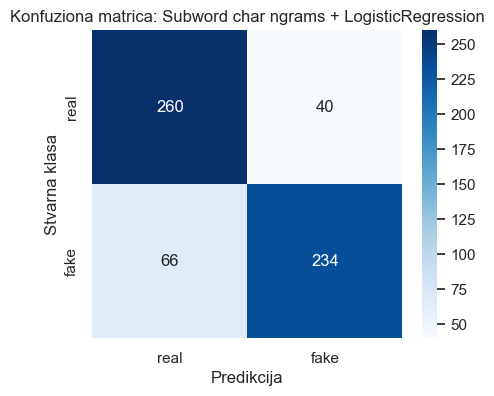

In [24]:
best_result = max(results, key=lambda row: row["f1"])

print("Najbolji eksperiment:", best_result["experiment"])
print("Accuracy:", round(best_result["accuracy"], 4))
print("Precision:", round(best_result["precision"], 4))
print("Recall:", round(best_result["recall"], 4))
print("F1:", round(best_result["f1"], 4))
print()
print(best_result["classification_report"])

plt.figure(figsize=(5, 4))
sns.heatmap(best_result["confusion_matrix"], annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.title(f"Konfuziona matrica: {best_result['experiment']}")
plt.xlabel("Predikcija")
plt.ylabel("Stvarna klasa")
plt.show()


In [25]:
error_df = df.loc[test_idx, ["job_title", "label", "full_text", "word_count", "lexical_diversity", "typo_proxy_count"]].copy()
error_df["predicted_label"] = pd.Series(best_result["y_pred"], index=test_idx).map({0: "real", 1: "fake"})
error_df["error_type"] = np.where(
    (error_df["label"] == "real") & (error_df["predicted_label"] == "fake"),
    "false_positive",
    np.where(
        (error_df["label"] == "fake") & (error_df["predicted_label"] == "real"),
        "false_negative",
        "correct",
    ),
)

errors = error_df[error_df["error_type"] != "correct"].copy()
errors["snippet"] = errors["full_text"].str.replace("\n", " ", regex=False).str.slice(0, 320)

print("Broj gresaka po tipu:")
display(errors["error_type"].value_counts().to_frame("count"))
display(errors[["error_type", "job_title", "label", "predicted_label", "word_count", "lexical_diversity", "typo_proxy_count", "snippet"]].head(8))


Broj gresaka po tipu:


,count
error_type,
false_negative,66
false_positive,40


,error_type,job_title,label,predicted_label,word_count,lexical_diversity,typo_proxy_count,snippet
2044,false_negative,Financial Reporting Analyst,fake,real,225,0.648889,14,Financial Reporting Analyst The r0le supports ...
2976,false_negative,Software Engineer,fake,real,246,0.638211,5,Software Engineer The position includes a mix ...
2737,false_negative,Sales Operations Associate,fake,real,236,0.665254,6,Sales Operations Associate The role supports a...
2601,false_positive,HR Generalist,real,fake,250,0.644000,7,HR Generalist We are looking for someone who c...
2777,false_negative,Data Analyst,fake,real,195,0.682051,5,Data Analyst The position includes a mix of ro...
2331,false_negative,Operations Coordinator,fake,real,273,0.604396,5,Operations Coordinator The role supports a sma...
2778,false_positive,Software Engineer,real,fake,310,0.638710,13,Software Engineer The position includes a mix ...
1040,false_negative,Product Designer,fake,real,220,0.636364,6,Product Designer Our team works in short plann...


In [26]:
interpret_config = next(config for config in EXPERIMENTS if config["name"] == "TF-IDF stemmed + LogisticRegression")
interpret_result = evaluate_config(interpret_config)
vectorizer = interpret_result["fitted"]["vectorizer"]
model = interpret_result["fitted"]["model"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = model.coef_[0]
top_fake = pd.DataFrame({"token_or_ngram": feature_names[np.argsort(coefs)[-20:][::-1]], "coefficient": np.sort(coefs)[-20:][::-1]})
top_real = pd.DataFrame({"token_or_ngram": feature_names[np.argsort(coefs)[:20]], "coefficient": np.sort(coefs)[:20]})

print("Najjacih 20 indikatora za fake klasu u interpretabilnom TF-IDF modelu:")
display(top_fake)
print("Najjacih 20 indikatora za real klasu u interpretabilnom TF-IDF modelu:")
display(top_real)


Najjacih 20 indikatora za fake klasu u interpretabilnom TF-IDF modelu:


,token_or_ngram,coefficient
0,channel,1.435690
1,assign,1.257821
2,account,1.212444
3,materi updat,1.210074
4,publicfac,1.210074
5,publicfac materi,1.210074
6,work publicfac,1.210074
7,support confidenti,1.210074
8,client work,1.199356
9,contact,1.168739


Najjacih 20 indikatora za real klasu u interpretabilnom TF-IDF modelu:


,token_or_ngram,coefficient
0,ad team,-1.005879
1,locat paid,-0.916987
2,practic partner,-0.916781
3,region work,-0.788490
4,workflow flexibl,-0.717192
5,earli ref,-0.666266
6,ref bonu,-0.660570
7,checkin paid,-0.645292
8,path recruit,-0.643510
9,window health,-0.628354


## 11. Zaključak

Različiti postupci predobrade menjaju veličinu rečnika i broj tokena, ali njihov uticaj na klasifikaciju nije podjednak. Normalizacija uklanja površinske varijacije, dok stemming i lematizacija dodatno grupišu srodne oblike reči. U ovom skupu razlike između više TF-IDF varijanti ostaju male, što ukazuje da osnovni tekst već sadrži dovoljno stabilne leksičke signale.

Karakterski n-grami ostvaruju konkurentne rezultate i pokazuju manji pad F1 mere na kontrolisano zašumljenom testu. To ih čini korisnim kada se očekuju tipografske greške, OCR zamene ili nepoznate varijante reči.

Lokalno trenirani Word2Vec, FastText-style i BERT-like modeli raspolažu samo informacijama iz relativno malog trening skupa. FastText-style reprezentacija koristi subword strukturu efikasnije od prosečnih Word2Vec embeddinga, dok mali Transformer bez pretreniranja nema prednost velikih jezičkih modela.

Za pouzdaniju primenu sistema bilo bi korisno uključiti oglase iz više izvora, proveriti stabilnost kroz vreme i porediti lokalne modele sa pretrained FastText ili BERT reprezentacijama. Posebnu pažnju treba posvetiti false negative slučajevima, jer neprepoznat lažni oglas predstavlja veći praktični rizik od dodatne ručne provere stvarnog oglasa.